<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/closed_loop_process_optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Closed-loop process optimization with NeqSim

**Audience.** Process, mechanical, and energy engineers who know basic Python and want to
use a rigorous thermodynamic process model inside a reproducible optimization loop.

**Prerequisites.** Familiarity with pressure, temperature, phase separation, and compressor
efficiency is useful. No local NeqSim installation or proprietary plant data is required.


## Learning objectives

After completing the notebook, you can:

1. create and flash a natural-gas fluid with a documented equation of state;
2. connect `Stream`, `Heater`, `Separator`, and `Compressor` objects in a `ProcessSystem`;
3. evaluate setpoints with fresh NeqSim objects so results do not depend on run order;
4. preserve and reproduce the original 15-case cooler/compressor power sweep;
5. audit mass, component, and equipment-energy balances;
6. put NeqSim inside a bounded closed-loop search; and
7. interpret feasibility, sensitivity, and model limitations before applying the workflow.


## Preservation checklist

The previous notebook contained four substantive examples and one substantive figure.
They are all retained and integrated:

- the original six-component SRK gas assay;
- the cooler-to-compressor base flowsheet at 7,500 kg/h;
- the 15 combinations of 10, 20, and 30 °C with 80–120 bara;
- the minimum-power selection subject to an outlet-pressure target; and
- the original power-versus-outlet-pressure line figure.

The line figure is recomputed with NeqSim 3.16.0 inputs during this run. New figures add
topology, feasibility, convergence, state-profile, and final-application views; none
replaces the original engineering message.


## 1. Clean Colab setup

The setup installs the latest public PyPI release only when NeqSim is absent. A Colab
runtime does not need a restart. The version and Python/Java runtimes are printed so a
result can be reproduced later.


In [1]:
import importlib.metadata
import platform
import subprocess
import sys

try:
    import neqsim
except ImportError:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
        ]
    )
    import neqsim

neqsim_version = importlib.metadata.version("neqsim")
java_version = platform.java_ver()[0]

if not java_version:
    java_version = subprocess.check_output(
        ["java", "-version"],
        stderr=subprocess.STDOUT,
        text=True,
    ).splitlines()[0]

print(f"NeqSim package: {neqsim_version}")
print(f"Python runtime: {platform.python_version()}")
print(f"Java runtime: {java_version}")


NeqSim package: 3.16.0
Python runtime: 3.12.13
Java runtime: openjdk version "17.0.19" 2026-04-21


In [2]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

from neqsim import jneqsim

COLORS = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "green": "#009E73",
    "red": "#D55E00",
    "purple": "#CC79A7",
    "sky": "#56B4E9",
    "grey": "#666666",
}

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)


## 2. Engineering problem and governing relations

The original question is retained: choose cooler and compressor setpoints that minimize
compressor power while meeting a minimum delivery pressure. The expanded application also
requires a minimum gas-product recovery so that power is not reduced by discarding too much
feed as condensate.

For a feasible decision vector $u = (T_c, p_d)$, the objective is:

$$
\min_u \dot{W}_{comp}(u)
$$

subject to $p_d \ge 100$ bara and gas recovery $R_g \ge 94$ wt%. Temperature $T_c$ is in
°C, delivery pressure $p_d$ is in bara, and compressor power $\dot{W}_{comp}$ is in kW.


A separator must close its total material balance:

$$
\dot{m}_{feed} = \dot{m}_{gas} + \dot{m}_{liquid}
$$

The component balance uses molar rates for every component. Compressor efficiency is
represented by:

$$
\eta_s = \frac{h_{out,s} - h_{in}}{h_{out} - h_{in}}
$$

Here $h$ is specific enthalpy in J/kg and $\eta_s$ is dimensionless. NeqSim evaluates the
real-gas flashes and equipment enthalpy changes; the notebook checks the reported duties
against stream enthalpy-rate differences.


## 3. Assumptions and validity limits

- Steady state, adiabatic compressor, and specified cooler outlet temperature.
- SRK with the classic mixing rule is used for hydrocarbon screening.
- Compressor isentropic efficiency is fixed at 0.78.
- Pressure drop through the cooler and separator is neglected.
- Synthetic compositions are mole fractions and contain no proprietary data.
- The optimizer evaluates a bounded engineering screen; it is not a plant APC controller.
- Equipment maps, anti-surge limits, mechanical constraints, heat-exchanger area, economics,
  hydrate risk, and uncertainty must be added before design or operations use.


## 4. Original fluid example: preserved and made explicit

The original six-component assay sums to one mole fraction. SRK is retained because the
example is a hydrocarbon-gas compression screen. Each evaluation constructs and flashes a
new fluid, which prevents setpoint history from leaking between cases.


In [3]:
original_composition = {
    "nitrogen": 0.01,
    "CO2": 0.02,
    "methane": 0.86,
    "ethane": 0.07,
    "propane": 0.03,
    "n-butane": 0.01,
}

original_basis = {
    "feed_temperature_c": 30.0,
    "feed_pressure_bara": 55.0,
    "feed_mass_flow_kg_h": 7500.0,
    "compressor_efficiency": 0.78,
    "minimum_delivery_pressure_bara": 100.0,
}

assert math.isclose(
    sum(original_composition.values()),
    1.0,
    rel_tol=0.0,
    abs_tol=1.0e-12,
)

display(
    pd.DataFrame(
        {
            "Component": list(original_composition),
            "Mole fraction [-]": list(original_composition.values()),
        }
    )
)


,Component,Mole fraction [-]
0,nitrogen,0.01
1,CO2,0.02
2,methane,0.86
3,ethane,0.07
4,propane,0.03
5,n-butane,0.01


In [4]:
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
ThermodynamicOperations = (
    jneqsim.thermodynamicoperations.ThermodynamicOperations
)
Stream = jneqsim.process.equipment.stream.Stream
Heater = jneqsim.process.equipment.heatexchanger.Heater
Separator = jneqsim.process.equipment.separator.Separator
Compressor = jneqsim.process.equipment.compressor.Compressor
ProcessSystem = jneqsim.process.processmodel.ProcessSystem


def build_fluid(composition, temperature_c, pressure_bara, flow_kg_h):
    fluid = SystemSrkEos(temperature_c + 273.15, pressure_bara)

    for component_name, mole_fraction in composition.items():
        fluid.addComponent(component_name, mole_fraction)

    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)
    fluid.setTotalFlowRate(flow_kg_h, "kg/hr")
    operations = ThermodynamicOperations(fluid)
    operations.TPflash()
    fluid.init(0)
    fluid.init(1)
    fluid.initPhysicalProperties()
    return fluid


In [5]:
original_feed_fluid = build_fluid(
    composition=original_composition,
    temperature_c=original_basis["feed_temperature_c"],
    pressure_bara=original_basis["feed_pressure_bara"],
    flow_kg_h=original_basis["feed_mass_flow_kg_h"],
)

original_feed_properties = pd.DataFrame(
    [
        {
            "Temperature [°C]": original_feed_fluid.getTemperature("C"),
            "Pressure [bara]": original_feed_fluid.getPressure("bara"),
            "Mass flow [kg/h]": original_feed_fluid.getFlowRate("kg/hr"),
            "Molar mass [kg/mol]": (
                original_feed_fluid.getMolarMass("kg/mol")
            ),
            "Density [kg/m³]": original_feed_fluid.getDensity("kg/m3"),
            "Enthalpy [kJ/kg]": (
                original_feed_fluid.getEnthalpy("J/kg") / 1000.0
            ),
        }
    ]
)
display(original_feed_properties.round(6))


,Temperature [°C],Pressure [bara],Mass flow [kg/h],Molar mass [kg/mol],Density [kg/m³],Enthalpy [kJ/kg]
0,30.0,55.0,7500.0,0.018966,46.87805,34.668645


The flashed feed table is the thermodynamic starting point. The process model below does
not copy numerical properties into equations: named NeqSim streams carry the fluid state
from the cooler to the compressor.


## 5. Process topology and solver workflow

`ProcessSystem.run()` executes the units in connection order. The first workflow preserves
the original Feed → Cooler → Compressor example. The final workflow inserts a separator so
condensed liquid cannot enter the compressor. Both workflows retrieve results from NeqSim
objects after convergence.


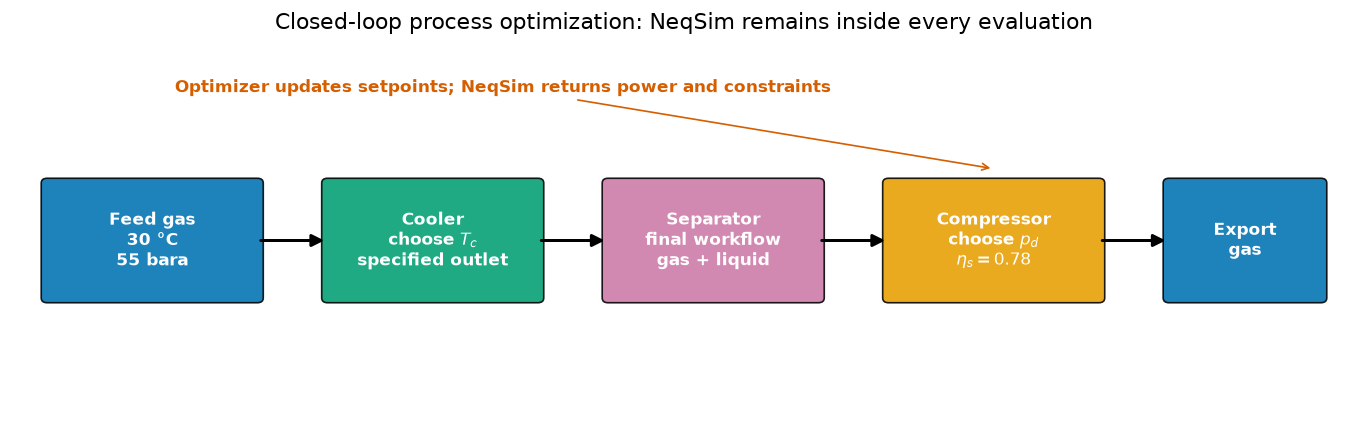

In [6]:
figure, axis = plt.subplots(figsize=(11.5, 3.8))
axis.set_xlim(0.0, 11.5)
axis.set_ylim(0.0, 4.0)
axis.axis("off")

boxes = [
    (0.3, 1.4, 1.8, 1.2, "Feed gas\n30 °C\n55 bara", "blue"),
    (2.7, 1.4, 1.8, 1.2, "Cooler\nchoose $T_c$\nspecified outlet", "green"),
    (5.1, 1.4, 1.8, 1.2, "Separator\nfinal workflow\ngas + liquid", "purple"),
    (7.5, 1.4, 1.8, 1.2, "Compressor\nchoose $p_d$\n$\\eta_s=0.78$", "orange"),
    (9.9, 1.4, 1.3, 1.2, "Export\ngas", "blue"),
]

for x_value, y_value, width, height, label, colour_key in boxes:
    patch = FancyBboxPatch(
        (x_value, y_value),
        width,
        height,
        boxstyle="round,pad=0.05",
        facecolor=COLORS[colour_key],
        edgecolor="black",
        alpha=0.88,
    )
    axis.add_patch(patch)
    axis.text(
        x_value + width / 2.0,
        y_value + height / 2.0,
        label,
        ha="center",
        va="center",
        color="white",
        fontweight="bold",
    )

for start_x, end_x in [(2.1, 2.7), (4.5, 5.1), (6.9, 7.5), (9.3, 9.9)]:
    axis.add_patch(
        FancyArrowPatch(
            (start_x, 2.0),
            (end_x, 2.0),
            arrowstyle="-|>",
            mutation_scale=15,
            linewidth=1.8,
            color="black",
        )
    )

axis.annotate(
    "Optimizer updates setpoints; NeqSim returns power and constraints",
    xy=(8.4, 2.75),
    xytext=(4.2, 3.55),
    arrowprops={"arrowstyle": "->", "color": COLORS["red"]},
    color=COLORS["red"],
    ha="center",
    fontweight="bold",
)
axis.set_title(
    "Closed-loop process optimization: NeqSim remains inside every evaluation",
    fontsize=13,
    pad=12,
)
plt.tight_layout()
plt.show()


The diagram distinguishes the model loop from a plant feedback loop. Here the optimizer
changes bounded setpoints, runs a complete fresh NeqSim flowsheet, reads power and
constraints, and decides the next evaluation.


## 6. Preserved cooler–compressor evaluator

The original equipment and operating basis are unchanged. The repair makes isentropic
efficiency explicit, uses current APIs, returns engineering checks, and builds a fresh
process for every case.


In [7]:
def simulate_original_case(cooler_temperature_c, outlet_pressure_bara):
    fluid = build_fluid(
        composition=original_composition,
        temperature_c=original_basis["feed_temperature_c"],
        pressure_bara=original_basis["feed_pressure_bara"],
        flow_kg_h=original_basis["feed_mass_flow_kg_h"],
    )
    case_name = (
        f"original_T{cooler_temperature_c:.0f}_"
        f"P{outlet_pressure_bara:.0f}"
    )
    feed = Stream(f"{case_name} feed", fluid)
    cooler = Heater(f"{case_name} cooler", feed)
    cooler.setOutTemperature(cooler_temperature_c, "C")
    compressor = Compressor(
        f"{case_name} compressor",
        cooler.getOutletStream(),
    )
    compressor.setOutletPressure(outlet_pressure_bara, "bara")
    compressor.setIsentropicEfficiency(
        original_basis["compressor_efficiency"]
    )
    process = ProcessSystem()

    for unit_operation in [feed, cooler, compressor]:
        process.add(unit_operation)

    process.run()
    suction = cooler.getOutletStream()
    discharge = compressor.getOutletStream()
    mass_flow_kg_s = suction.getFlowRate("kg/sec")
    enthalpy_rate_change_w = mass_flow_kg_s * (
        discharge.getFluid().getEnthalpy("J/kg")
        - suction.getFluid().getEnthalpy("J/kg")
    )
    result = {
        "Cooler temperature [°C]": cooler_temperature_c,
        "Outlet pressure [bara]": outlet_pressure_bara,
        "Power [kW]": compressor.getPower("kW"),
        "Discharge temperature [°C]": discharge.getTemperature("C"),
        "Suction density [kg/m³]": suction.getFluid().getDensity("kg/m3"),
        "Mass residual [kg/h]": (
            feed.getFlowRate("kg/hr")
            - discharge.getFlowRate("kg/hr")
        ),
        "Compressor energy residual [W]": (
            compressor.getPower("W") - enthalpy_rate_change_w
        ),
    }
    objects = {
        "process": process,
        "feed": feed,
        "cooler": cooler,
        "compressor": compressor,
    }
    return {"result": result, "objects": objects}


In [8]:
original_base_case = simulate_original_case(
    cooler_temperature_c=20.0,
    outlet_pressure_bara=100.0,
)
display(pd.DataFrame([original_base_case["result"]]).round(6))


,Cooler temperature [°C],Outlet pressure [bara],Power [kW],Discharge temperature [°C],Suction density [kg/m³],Mass residual [kg/h],Compressor energy residual [W]
0,20.0,100.0,193.441842,72.183655,49.455972,0.0,0.0


The base case provides a transparent checkpoint before optimization. Power is positive,
mass is conserved, and the compressor duty matches the gas enthalpy-rate rise at stored
precision.


## 7. Original 15-case sweep

The previous notebook evaluated five outlet pressures at three cooler temperatures. The
same grid and units are retained. Independent construction makes the result invariant to
loop order.


In [9]:
original_temperatures_c = [10.0, 20.0, 30.0]
original_pressures_bara = [80.0, 90.0, 100.0, 110.0, 120.0]
original_rows = []

for outlet_pressure_bara in original_pressures_bara:
    for cooler_temperature_c in original_temperatures_c:
        case = simulate_original_case(
            cooler_temperature_c=cooler_temperature_c,
            outlet_pressure_bara=outlet_pressure_bara,
        )
        original_rows.append(case["result"])

original_results = pd.DataFrame(original_rows)
display(original_results.round(6))


,Cooler temperature [°C],Outlet pressure [bara],Power [kW],Discharge temperature [°C],Suction density [kg/m³],Mass residual [kg/h],Compressor energy residual [W]
0,10.0,80.0,110.880728,41.565338,52.449972,0.0,0.0
1,20.0,80.0,117.410689,52.294944,49.455972,0.0,0.0
2,30.0,80.0,123.699970,62.963558,46.878050,0.0,0.0
3,10.0,90.0,148.274234,51.780285,52.449972,0.0,0.0
4,20.0,90.0,156.922717,62.736349,49.455972,0.0,0.0
5,30.0,90.0,165.252568,73.609452,46.878050,0.0,0.0
6,10.0,100.0,182.875458,61.025717,52.449972,0.0,-0.0
7,20.0,100.0,193.441842,72.183655,49.455972,0.0,0.0
8,30.0,100.0,203.619419,83.237947,46.878050,0.0,0.0
9,10.0,110.0,215.175326,69.472385,52.449972,0.0,0.0


In [10]:
feasible_original_results = original_results[
    original_results["Outlet pressure [bara]"]
    >= original_basis["minimum_delivery_pressure_bara"]
]
original_optimum = feasible_original_results.loc[
    feasible_original_results["Power [kW]"].idxmin()
]
display(original_optimum.to_frame("Selected original case").round(6))


,Selected original case
Cooler temperature [°C],10.000000
Outlet pressure [bara],100.000000
Power [kW],182.875458
Discharge temperature [°C],61.025717
Suction density [kg/m³],52.449972
Mass residual [kg/h],0.000000
Compressor energy residual [W],-0.000000


The constrained selection preserves the original intent. Cases below 100 bara are
deliberately excluded even if they use less power. Within this basis, colder suction
reduces specific compression work.


## 8. Preserved and numerically refreshed power figure

This is the previous notebook's substantive figure: compressor power versus discharge
pressure, with one line for each cooler temperature. Values are freshly recomputed from
independent NeqSim 3.16.0 cases.


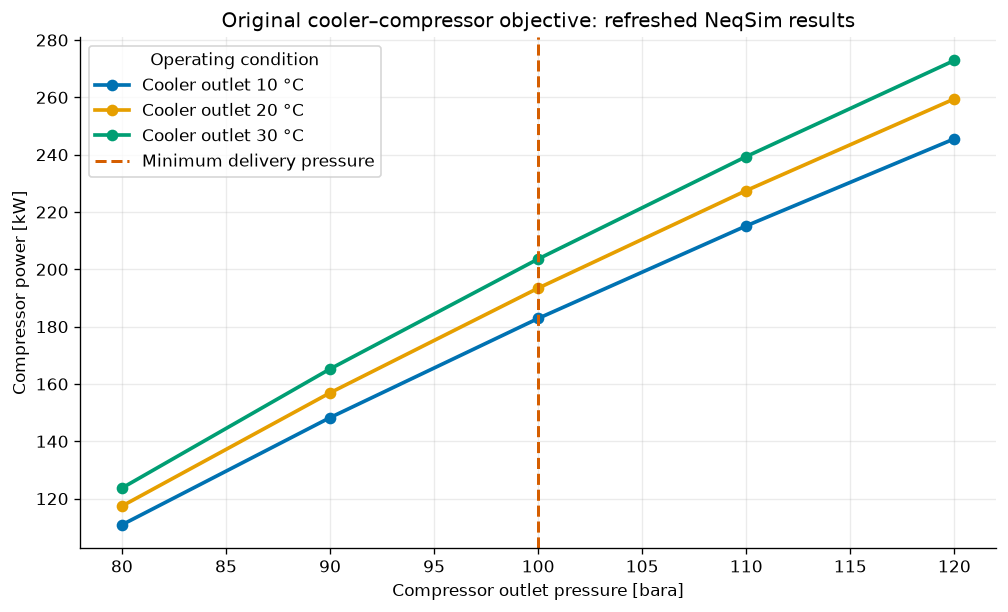

In [11]:
original_power_pivot = original_results.pivot(
    index="Outlet pressure [bara]",
    columns="Cooler temperature [°C]",
    values="Power [kW]",
)
figure, axis = plt.subplots(figsize=(8.5, 5.2))

for index, temperature_c in enumerate(original_temperatures_c):
    axis.plot(
        original_power_pivot.index,
        original_power_pivot[temperature_c],
        marker="o",
        linewidth=2.2,
        color=list(COLORS.values())[index],
        label=f"Cooler outlet {temperature_c:.0f} °C",
    )

axis.axvline(
    original_basis["minimum_delivery_pressure_bara"],
    color=COLORS["red"],
    linestyle="--",
    linewidth=1.8,
    label="Minimum delivery pressure",
)
axis.set_xlabel("Compressor outlet pressure [bara]")
axis.set_ylabel("Compressor power [kW]")
axis.set_title(
    "Original cooler–compressor objective: refreshed NeqSim results"
)
axis.legend(title="Operating condition")
plt.tight_layout()
plt.show()


Power increases monotonically with outlet pressure at every retained temperature. At a
fixed pressure, the 10 °C suction condition requires the least power. The dashed line makes
the feasibility boundary visible instead of allowing an infeasible low-pressure point to
appear optimal.


## 9. Numerical checks on the preserved study

The assertions test physical trends, conservation, equipment-energy bookkeeping, and
order independence. The reversed sweep re-evaluates the same corners with fresh objects.


In [12]:
original_check_results = []

for temperature_c in original_temperatures_c:
    temperature_slice = original_results[
        original_results["Cooler temperature [°C]"] == temperature_c
    ].sort_values("Outlet pressure [bara]")
    original_check_results.append(
        np.all(np.diff(temperature_slice["Power [kW]"]) > 0.0)
    )

for pressure_bara in original_pressures_bara:
    pressure_slice = original_results[
        original_results["Outlet pressure [bara]"] == pressure_bara
    ].sort_values("Cooler temperature [°C]")
    original_check_results.append(
        np.all(np.diff(pressure_slice["Power [kW]"]) > 0.0)
    )

reversed_corner = simulate_original_case(
    cooler_temperature_c=10.0,
    outlet_pressure_bara=120.0,
)["result"]["Power [kW]"]
forward_corner = original_results.loc[
    (
        original_results["Cooler temperature [°C]"] == 10.0
    )
    & (
        original_results["Outlet pressure [bara]"] == 120.0
    ),
    "Power [kW]",
].iloc[0]
original_check_results.extend(
    [
        original_results["Power [kW]"].gt(0.0).all(),
        original_results["Discharge temperature [°C]"].gt(
            original_results["Cooler temperature [°C]"]
        ).all(),
        original_results["Mass residual [kg/h]"].abs().max() < 1.0e-8,
        original_results[
            "Compressor energy residual [W]"
        ].abs().max()
        < 1.0e-6,
        math.isclose(
            reversed_corner,
            forward_corner,
            rel_tol=1.0e-10,
            abs_tol=1.0e-10,
        ),
    ]
)

assert all(original_check_results)
print(f"Preserved-study checks passed: {len(original_check_results)}")


Preserved-study checks passed: 13


These checks validate behavior for the stated grid. They do not prove compressor map
suitability or EOS accuracy against laboratory data.


## 10. Final application: gas conditioning before compression

The original dry-gas workflow is now extended with a heavier synthetic C1–C6 assay and an
equilibrium separator. Cooling can condense hydrocarbons; the compressor receives only the
gas outlet. The minimum 94 wt% gas recovery makes the power objective nontrivial.


In [13]:
conditioning_composition = {
    "nitrogen": 0.010,
    "CO2": 0.020,
    "methane": 0.830,
    "ethane": 0.070,
    "propane": 0.040,
    "n-butane": 0.015,
    "n-pentane": 0.010,
    "n-hexane": 0.005,
}

conditioning_basis = {
    **original_basis,
    "minimum_gas_recovery_wt_pct": 94.0,
    "maximum_discharge_temperature_c": 120.0,
}

assert math.isclose(
    sum(conditioning_composition.values()),
    1.0,
    rel_tol=0.0,
    abs_tol=1.0e-12,
)


In [14]:
def component_molar_rates(stream_object, component_names):
    fluid = stream_object.getFluid()
    total_molar_rate = stream_object.getFlowRate("mole/sec")
    return np.asarray(
        [
            total_molar_rate
            * fluid.getComponent(component_name).getz()
            for component_name in component_names
        ]
    )


def simulate_conditioning_case(cooler_temperature_c, outlet_pressure_bara):
    fluid = build_fluid(
        composition=conditioning_composition,
        temperature_c=conditioning_basis["feed_temperature_c"],
        pressure_bara=conditioning_basis["feed_pressure_bara"],
        flow_kg_h=conditioning_basis["feed_mass_flow_kg_h"],
    )
    case_name = (
        f"conditioning_T{cooler_temperature_c:.1f}_"
        f"P{outlet_pressure_bara:.1f}"
    )
    feed = Stream(f"{case_name} feed", fluid)
    cooler = Heater(f"{case_name} cooler", feed)
    cooler.setOutTemperature(cooler_temperature_c, "C")
    separator = Separator(
        f"{case_name} separator",
        cooler.getOutletStream(),
    )
    compressor = Compressor(
        f"{case_name} compressor",
        separator.getGasOutStream(),
    )
    compressor.setOutletPressure(outlet_pressure_bara, "bara")
    compressor.setIsentropicEfficiency(
        conditioning_basis["compressor_efficiency"]
    )
    process = ProcessSystem()

    for unit_operation in [feed, cooler, separator, compressor]:
        process.add(unit_operation)

    process.run()
    gas_product = separator.getGasOutStream()
    liquid_product = separator.getLiquidOutStream()
    discharge = compressor.getOutletStream()
    feed_flow_kg_h = feed.getFlowRate("kg/hr")
    gas_flow_kg_h = gas_product.getFlowRate("kg/hr")
    liquid_flow_kg_h = liquid_product.getFlowRate("kg/hr")
    compressor_enthalpy_change_w = gas_product.getFlowRate(
        "kg/sec"
    ) * (
        discharge.getFluid().getEnthalpy("J/kg")
        - gas_product.getFluid().getEnthalpy("J/kg")
    )
    cooler_enthalpy_change_w = feed.getFlowRate("kg/sec") * (
        cooler.getOutletStream().getFluid().getEnthalpy("J/kg")
        - feed.getFluid().getEnthalpy("J/kg")
    )
    gas_recovery_wt_pct = 100.0 * gas_flow_kg_h / feed_flow_kg_h
    feasible = (
        outlet_pressure_bara
        >= conditioning_basis["minimum_delivery_pressure_bara"]
        and gas_recovery_wt_pct
        >= conditioning_basis["minimum_gas_recovery_wt_pct"]
        and discharge.getTemperature("C")
        <= conditioning_basis["maximum_discharge_temperature_c"]
    )
    result = {
        "Cooler temperature [°C]": cooler_temperature_c,
        "Outlet pressure [bara]": outlet_pressure_bara,
        "Feed flow [kg/h]": feed_flow_kg_h,
        "Gas flow [kg/h]": gas_flow_kg_h,
        "Liquid flow [kg/h]": liquid_flow_kg_h,
        "Gas recovery [wt%]": gas_recovery_wt_pct,
        "Cooling load [kW]": -cooler.getDuty() / 1000.0,
        "Power [kW]": compressor.getPower("kW"),
        "Discharge temperature [°C]": discharge.getTemperature("C"),
        "Mass residual [kg/h]": (
            feed_flow_kg_h - gas_flow_kg_h - liquid_flow_kg_h
        ),
        "Cooler energy residual [W]": (
            cooler.getDuty() - cooler_enthalpy_change_w
        ),
        "Compressor energy residual [W]": (
            compressor.getPower("W")
            - compressor_enthalpy_change_w
        ),
        "Feasible": feasible,
    }
    objects = {
        "process": process,
        "feed": feed,
        "cooler": cooler,
        "separator": separator,
        "gas product": gas_product,
        "liquid product": liquid_product,
        "compressor": compressor,
    }
    return {"result": result, "objects": objects}


In [15]:
conditioning_base_case = simulate_conditioning_case(
    cooler_temperature_c=15.0,
    outlet_pressure_bara=105.0,
)
conditioning_base_result = conditioning_base_case["result"]
display(pd.DataFrame([conditioning_base_result]).round(6))


,Cooler temperature [°C],Outlet pressure [bara],Feed flow [kg/h],Gas flow [kg/h],Liquid flow [kg/h],Gas recovery [wt%],Cooling load [kW],Power [kW],Discharge temperature [°C],Mass residual [kg/h],Cooler energy residual [W],Compressor energy residual [W],Feasible
0,15.0,105.0,7500.0,7225.481725,274.518275,96.339756,97.566917,183.593043,69.323729,-0.0,0.0,-0.0,True


The base application produces both gas and condensate. The separator changes compressor
throughput with temperature, so a lower suction temperature affects both gas density and
mass flow.


## 11. Balance audit for the final application

Component molar flow is calculated from each stream's total molar rate and NeqSim overall
component fraction. Residuals are reported rather than hidden behind assertions.


In [16]:
application_objects = conditioning_base_case["objects"]
component_names = list(conditioning_composition)
feed_component_rates = component_molar_rates(
    application_objects["feed"],
    component_names,
)
gas_component_rates = component_molar_rates(
    application_objects["gas product"],
    component_names,
)
liquid_component_rates = component_molar_rates(
    application_objects["liquid product"],
    component_names,
)
component_residuals = (
    feed_component_rates
    - gas_component_rates
    - liquid_component_rates
)
component_balance_table = pd.DataFrame(
    {
        "Component": component_names,
        "Feed [mol/s]": feed_component_rates,
        "Gas [mol/s]": gas_component_rates,
        "Liquid [mol/s]": liquid_component_rates,
        "Residual [mol/s]": component_residuals,
    }
)
display(component_balance_table.round(12))


,Component,Feed [mol/s],Gas [mol/s],Liquid [mol/s],Residual [mol/s]
0,nitrogen,1.022794,1.021002,0.001792,1.000000e-12
1,CO2,2.045589,2.025367,0.020222,0.000000e+00
2,methane,84.891929,84.506112,0.385816,3.400000e-11
3,ethane,7.159560,7.023482,0.136078,-1.000000e-12
4,propane,4.091177,3.879522,0.211655,-6.000000e-12
5,n-butane,1.534191,1.331905,0.202287,-7.000000e-12
6,n-pentane,1.022794,0.728600,0.294195,-1.100000e-11
7,n-hexane,0.511397,0.247796,0.263602,-1.000000e-11


In [17]:
application_audit = pd.DataFrame(
    [
        {
            "Check": "Total mass balance",
            "Residual": conditioning_base_result[
                "Mass residual [kg/h]"
            ],
            "Unit": "kg/h",
        },
        {
            "Check": "Maximum component balance",
            "Residual": np.max(np.abs(component_residuals)),
            "Unit": "mol/s",
        },
        {
            "Check": "Cooler energy balance",
            "Residual": conditioning_base_result[
                "Cooler energy residual [W]"
            ],
            "Unit": "W",
        },
        {
            "Check": "Compressor energy balance",
            "Residual": conditioning_base_result[
                "Compressor energy residual [W]"
            ],
            "Unit": "W",
        },
    ]
)
display(application_audit)


,Check,Residual,Unit
0,Total mass balance,-6.354810e-09,kg/h
1,Maximum component balance,3.391937e-11,mol/s
2,Cooler energy balance,0.000000e+00,W
3,Compressor energy balance,-2.910383e-11,W


Residuals close at numerical precision relative to the 7,500 kg/h feed. These balances
verify process bookkeeping and unit conversions, while model validation still requires
representative phase-equilibrium and compressor data.


## 12. State-profile visualization

Temperature, pressure, and flow are retrieved from the final NeqSim objects. A profile
makes the cooling, separation, and compression steps visible in physical units.


,Location,Temperature [°C],Pressure [bara],Mass flow [kg/h]
0,Feed,30.000000,55.0,7500.000000
1,After cooler,15.000000,55.0,7500.000000
2,Separator gas,15.000000,55.0,7225.481725
3,Compressor outlet,69.323729,105.0,7225.481725


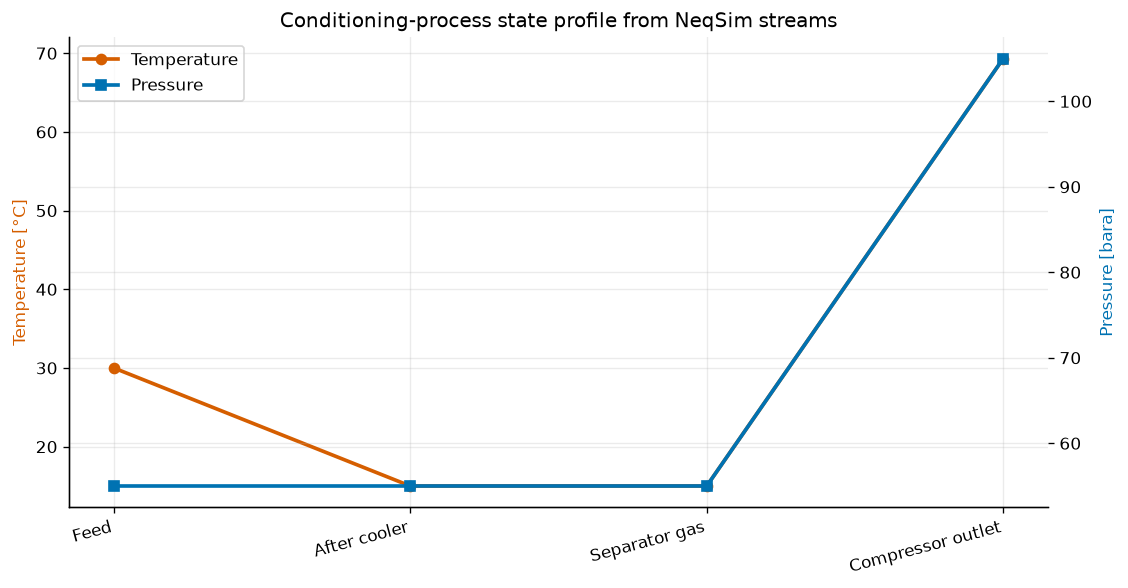

In [18]:
profile_streams = [
    ("Feed", application_objects["feed"]),
    ("After cooler", application_objects["cooler"].getOutletStream()),
    ("Separator gas", application_objects["gas product"]),
    (
        "Compressor outlet",
        application_objects["compressor"].getOutletStream(),
    ),
]
state_profile = pd.DataFrame(
    [
        {
            "Location": location_name,
            "Temperature [°C]": stream_object.getTemperature("C"),
            "Pressure [bara]": stream_object.getPressure("bara"),
            "Mass flow [kg/h]": stream_object.getFlowRate("kg/hr"),
        }
        for location_name, stream_object in profile_streams
    ]
)
display(state_profile.round(6))

x_positions = np.arange(len(state_profile))
figure, temperature_axis = plt.subplots(figsize=(9.5, 5.0))
pressure_axis = temperature_axis.twinx()
temperature_axis.plot(
    x_positions,
    state_profile["Temperature [°C]"],
    color=COLORS["red"],
    marker="o",
    linewidth=2.2,
    label="Temperature",
)
pressure_axis.plot(
    x_positions,
    state_profile["Pressure [bara]"],
    color=COLORS["blue"],
    marker="s",
    linewidth=2.2,
    label="Pressure",
)
temperature_axis.set_xticks(x_positions)
temperature_axis.set_xticklabels(
    state_profile["Location"],
    rotation=15,
    ha="right",
)
temperature_axis.set_ylabel("Temperature [°C]", color=COLORS["red"])
pressure_axis.set_ylabel("Pressure [bara]", color=COLORS["blue"])
temperature_axis.set_title(
    "Conditioning-process state profile from NeqSim streams"
)
lines = temperature_axis.lines + pressure_axis.lines
temperature_axis.legend(
    lines,
    [line.get_label() for line in lines],
    loc="upper left",
)
plt.tight_layout()
plt.show()


The cooler lowers temperature without a modeled pressure drop. The separator removes
condensate, reducing gas mass flow, and the compressor raises both pressure and
temperature.


## 13. Feasibility map

A bounded 30-case screen shows the complete response surface before the optimizer is used.
This guards against accepting a local search result without understanding constraints.


In [19]:
application_temperatures_c = [5.0, 10.0, 15.0, 20.0, 25.0, 30.0]
application_pressures_bara = [95.0, 100.0, 105.0, 110.0, 115.0]
application_rows = []

for cooler_temperature_c in application_temperatures_c:
    for outlet_pressure_bara in application_pressures_bara:
        case = simulate_conditioning_case(
            cooler_temperature_c=cooler_temperature_c,
            outlet_pressure_bara=outlet_pressure_bara,
        )
        application_rows.append(case["result"])

application_results = pd.DataFrame(application_rows)
feasible_application_results = application_results[
    application_results["Feasible"]
]
grid_optimum = feasible_application_results.loc[
    feasible_application_results["Power [kW]"].idxmin()
]
display(grid_optimum.to_frame("Best feasible grid case").round(6))


,Best feasible grid case
Cooler temperature [°C],10.0
Outlet pressure [bara],100.0
Feed flow [kg/h],7500.0
Gas flow [kg/h],7115.033844
Liquid flow [kg/h],384.966156
Gas recovery [wt%],94.867118
Cooling load [kW],131.736758
Power [kW],163.141881
Discharge temperature [°C],59.799572
Mass residual [kg/h],-0.0


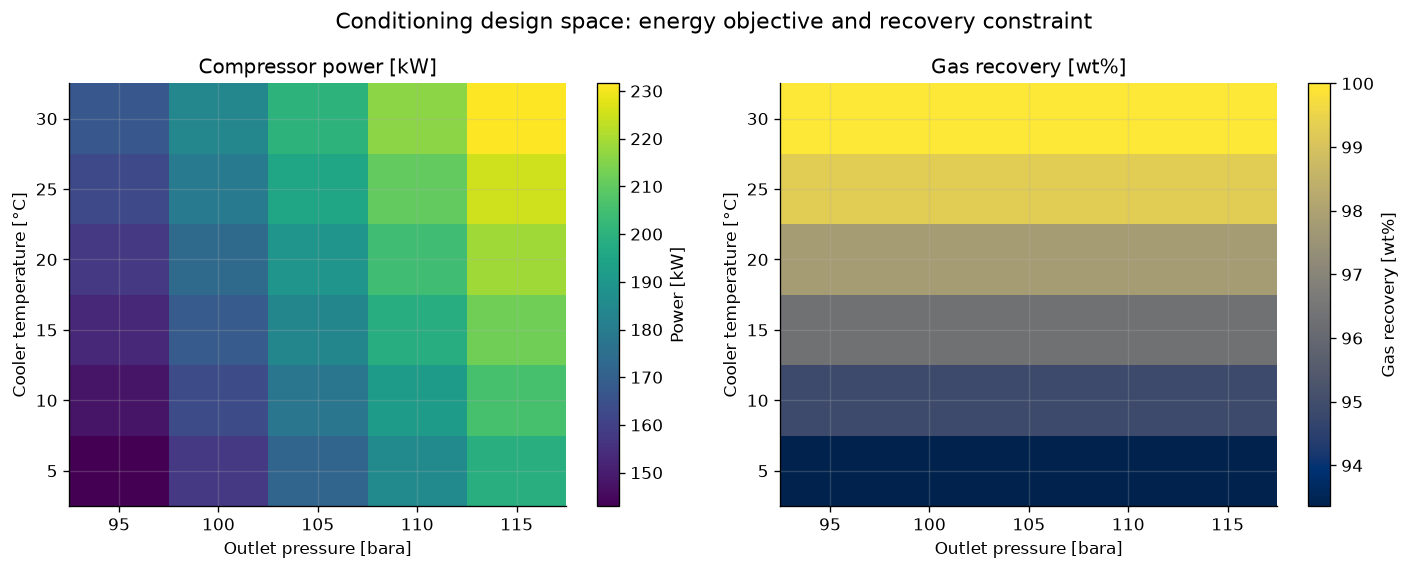

In [20]:
power_grid = application_results.pivot(
    index="Cooler temperature [°C]",
    columns="Outlet pressure [bara]",
    values="Power [kW]",
)
recovery_grid = application_results.pivot(
    index="Cooler temperature [°C]",
    columns="Outlet pressure [bara]",
    values="Gas recovery [wt%]",
)
figure, axes = plt.subplots(1, 2, figsize=(12.0, 4.8))

power_image = axes[0].imshow(
    power_grid.values,
    origin="lower",
    aspect="auto",
    cmap="viridis",
)
recovery_image = axes[1].imshow(
    recovery_grid.values,
    origin="lower",
    aspect="auto",
    cmap="cividis",
)

for axis, title in zip(
    axes,
    ["Compressor power [kW]", "Gas recovery [wt%]"],
):
    axis.set_xticks(np.arange(len(power_grid.columns)))
    axis.set_xticklabels([f"{value:.0f}" for value in power_grid.columns])
    axis.set_yticks(np.arange(len(power_grid.index)))
    axis.set_yticklabels([f"{value:.0f}" for value in power_grid.index])
    axis.set_xlabel("Outlet pressure [bara]")
    axis.set_ylabel("Cooler temperature [°C]")
    axis.set_title(title)

figure.colorbar(power_image, ax=axes[0], label="Power [kW]")
figure.colorbar(recovery_image, ax=axes[1], label="Gas recovery [wt%]")
figure.suptitle(
    "Conditioning design space: energy objective and recovery constraint",
    fontsize=13,
)
plt.tight_layout()
plt.show()


Colder operation reduces compressor power by removing liquid and increasing suction
density, but the 5 °C row violates the gas-recovery constraint. Higher delivery pressure
increases power without changing separator recovery in this simplified topology.


## 14. Bounded closed-loop search

The optimizer starts away from the solution. At each iteration it evaluates neighboring
temperature and pressure setpoints with fresh NeqSim flowsheets, accepts the feasible point
with the lowest power, and halves the step size when no improvement is found.


In [21]:
def run_closed_loop_search():
    current_temperature_c = 25.0
    current_pressure_bara = 110.0
    temperature_step_c = 5.0
    pressure_step_bara = 5.0
    history = []
    evaluation_cache = {}

    def evaluate(temperature_c, pressure_bara):
        key = (round(temperature_c, 6), round(pressure_bara, 6))

        if key not in evaluation_cache:
            evaluation_cache[key] = simulate_conditioning_case(
                cooler_temperature_c=temperature_c,
                outlet_pressure_bara=pressure_bara,
            )["result"]

        return evaluation_cache[key]

    current_result = evaluate(
        current_temperature_c,
        current_pressure_bara,
    )

    for iteration in range(12):
        candidates = []

        for temperature_offset, pressure_offset in [
            (0.0, 0.0),
            (-temperature_step_c, 0.0),
            (temperature_step_c, 0.0),
            (0.0, -pressure_step_bara),
            (0.0, pressure_step_bara),
        ]:
            candidate_temperature_c = float(
                np.clip(
                    current_temperature_c + temperature_offset,
                    5.0,
                    30.0,
                )
            )
            candidate_pressure_bara = float(
                np.clip(
                    current_pressure_bara + pressure_offset,
                    95.0,
                    115.0,
                )
            )
            candidates.append(
                evaluate(
                    candidate_temperature_c,
                    candidate_pressure_bara,
                )
            )

        feasible_candidates = [
            candidate
            for candidate in candidates
            if candidate["Feasible"]
        ]
        best_candidate = min(
            feasible_candidates,
            key=lambda candidate: candidate["Power [kW]"],
        )
        improved = (
            best_candidate["Power [kW]"]
            < current_result["Power [kW]"] - 1.0e-9
        )

        if improved:
            current_result = best_candidate
            current_temperature_c = best_candidate[
                "Cooler temperature [°C]"
            ]
            current_pressure_bara = best_candidate[
                "Outlet pressure [bara]"
            ]
        else:
            temperature_step_c /= 2.0
            pressure_step_bara /= 2.0

        history.append(
            {
                "Iteration": iteration,
                "Cooler temperature [°C]": current_temperature_c,
                "Outlet pressure [bara]": current_pressure_bara,
                "Power [kW]": current_result["Power [kW]"],
                "Gas recovery [wt%]": current_result[
                    "Gas recovery [wt%]"
                ],
                "Temperature step [°C]": temperature_step_c,
                "Pressure step [bar]": pressure_step_bara,
            }
        )

    return {
        "result": current_result,
        "history": pd.DataFrame(history),
        "evaluation_count": len(evaluation_cache),
    }


closed_loop = run_closed_loop_search()
display(closed_loop["history"].round(6))
display(
    pd.DataFrame([closed_loop["result"]]).round(6)
)
print(f"Unique NeqSim evaluations: {closed_loop['evaluation_count']}")


Unique NeqSim evaluations: 39


,Iteration,Cooler temperature [°C],Outlet pressure [bara],Power [kW],Gas recovery [wt%],Temperature step [°C],Pressure step [bar]
0,0,25.0000,105.0,194.960266,99.260020,5.00000,5.00000
1,1,25.0000,100.0,178.998939,99.260020,5.00000,5.00000
2,2,20.0000,100.0,173.792710,97.797838,5.00000,5.00000
3,3,15.0000,100.0,168.511578,96.339756,5.00000,5.00000
4,4,10.0000,100.0,163.141881,94.867118,5.00000,5.00000
5,5,10.0000,100.0,163.141881,94.867118,2.50000,2.50000
6,6,7.5000,100.0,160.419417,94.120081,2.50000,2.50000
7,7,7.5000,100.0,160.419417,94.120081,1.25000,1.25000
8,8,7.5000,100.0,160.419417,94.120081,0.62500,0.62500
9,9,7.5000,100.0,160.419417,94.120081,0.31250,0.31250


,Cooler temperature [°C],Outlet pressure [bara],Feed flow [kg/h],Gas flow [kg/h],Liquid flow [kg/h],Gas recovery [wt%],Cooling load [kW],Power [kW],Discharge temperature [°C],Mass residual [kg/h],Cooler energy residual [W],Compressor energy residual [W],Feasible
0,7.1875,100.0,7500.0,7051.953737,448.046263,94.02605,151.128652,160.077211,56.796131,-0.0,0.0,0.0,True


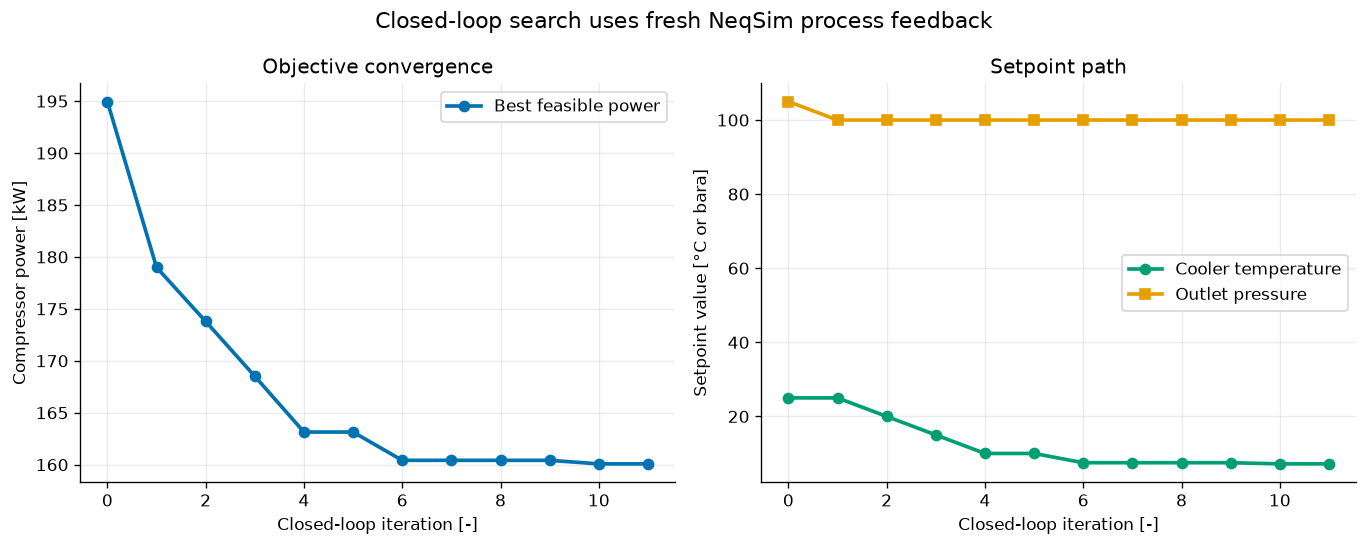

In [22]:
convergence_history = closed_loop["history"]
figure, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
axes[0].plot(
    convergence_history["Iteration"],
    convergence_history["Power [kW]"],
    color=COLORS["blue"],
    marker="o",
    linewidth=2.2,
    label="Best feasible power",
)
axes[0].set_xlabel("Closed-loop iteration [-]")
axes[0].set_ylabel("Compressor power [kW]")
axes[0].set_title("Objective convergence")
axes[0].legend()

axes[1].plot(
    convergence_history["Iteration"],
    convergence_history["Cooler temperature [°C]"],
    color=COLORS["green"],
    marker="o",
    linewidth=2.2,
    label="Cooler temperature",
)
axes[1].plot(
    convergence_history["Iteration"],
    convergence_history["Outlet pressure [bara]"],
    color=COLORS["orange"],
    marker="s",
    linewidth=2.2,
    label="Outlet pressure",
)
axes[1].set_xlabel("Closed-loop iteration [-]")
axes[1].set_ylabel("Setpoint value [°C or bara]")
axes[1].set_title("Setpoint path")
axes[1].legend()
figure.suptitle(
    "Closed-loop search uses fresh NeqSim process feedback",
    fontsize=13,
)
plt.tight_layout()
plt.show()


The search moves toward the lowest feasible cooler temperature and pressure. Step
reductions after the optimum is reached demonstrate bounded termination rather than
silently relying on the grid result.


## 15. Independent optimizer validation

The closed-loop result is compared with both the exhaustive grid and an independent
bisection on the 94 wt% recovery boundary at 100 bara. The comparison is an algorithm
check, not an external thermodynamic benchmark.


In [23]:
def find_recovery_boundary():
    lower_temperature_c = 5.0
    upper_temperature_c = 10.0

    for _ in range(18):
        midpoint_temperature_c = (
            lower_temperature_c + upper_temperature_c
        ) / 2.0
        midpoint_result = simulate_conditioning_case(
            cooler_temperature_c=midpoint_temperature_c,
            outlet_pressure_bara=100.0,
        )["result"]

        if (
            midpoint_result["Gas recovery [wt%]"]
            >= conditioning_basis["minimum_gas_recovery_wt_pct"]
        ):
            upper_temperature_c = midpoint_temperature_c
        else:
            lower_temperature_c = midpoint_temperature_c

    return simulate_conditioning_case(
        cooler_temperature_c=upper_temperature_c,
        outlet_pressure_bara=100.0,
    )["result"]


closed_loop_result = closed_loop["result"]
bisection_reference = find_recovery_boundary()
optimizer_comparison = pd.DataFrame(
    [
        {
            "Method": "Exhaustive grid",
            "Temperature [°C]": grid_optimum[
                "Cooler temperature [°C]"
            ],
            "Pressure [bara]": grid_optimum[
                "Outlet pressure [bara]"
            ],
            "Power [kW]": grid_optimum["Power [kW]"],
            "Gas recovery [wt%]": grid_optimum[
                "Gas recovery [wt%]"
            ],
        },
        {
            "Method": "Recovery-bound bisection",
            "Temperature [°C]": bisection_reference[
                "Cooler temperature [°C]"
            ],
            "Pressure [bara]": bisection_reference[
                "Outlet pressure [bara]"
            ],
            "Power [kW]": bisection_reference["Power [kW]"],
            "Gas recovery [wt%]": bisection_reference[
                "Gas recovery [wt%]"
            ],
        },
        {
            "Method": "Closed-loop search",
            "Temperature [°C]": closed_loop_result[
                "Cooler temperature [°C]"
            ],
            "Pressure [bara]": closed_loop_result[
                "Outlet pressure [bara]"
            ],
            "Power [kW]": closed_loop_result["Power [kW]"],
            "Gas recovery [wt%]": closed_loop_result[
                "Gas recovery [wt%]"
            ],
        },
    ]
)
display(optimizer_comparison.round(8))


,Method,Temperature [°C],Pressure [bara],Power [kW],Gas recovery [wt%]
0,Exhaustive grid,10.000000,100.0,163.141881,94.867118
1,Recovery-bound bisection,7.101021,100.0,159.982434,94.000001
2,Closed-loop search,7.187500,100.0,160.077211,94.026050


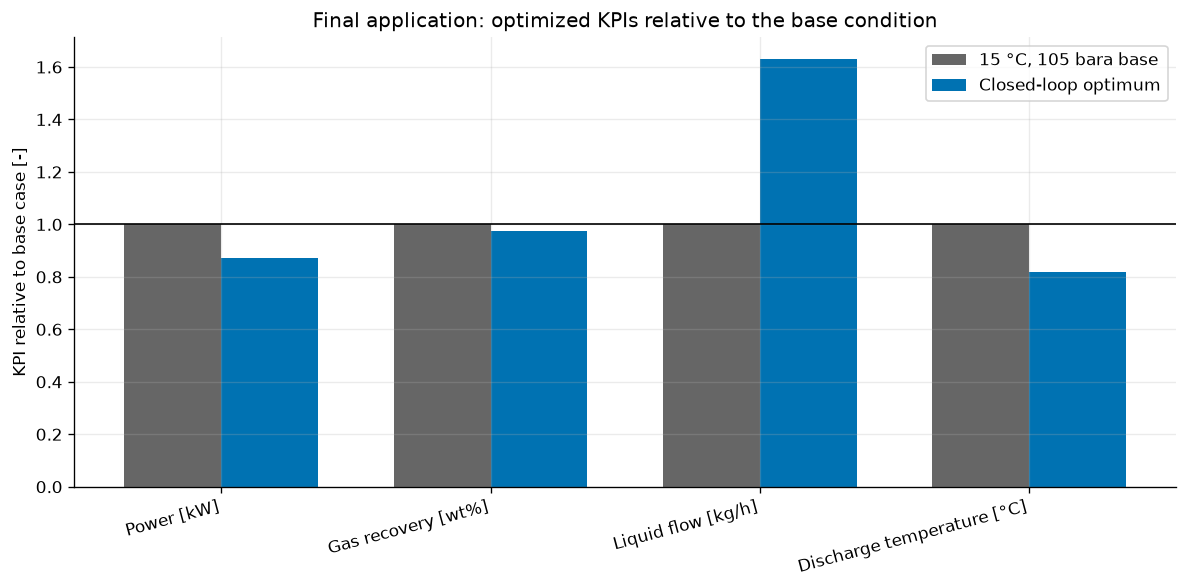

In [24]:
kpi_names = [
    "Power [kW]",
    "Gas recovery [wt%]",
    "Liquid flow [kg/h]",
    "Discharge temperature [°C]",
]
base_values = [
    conditioning_base_result["Power [kW]"],
    conditioning_base_result["Gas recovery [wt%]"],
    conditioning_base_result["Liquid flow [kg/h]"],
    conditioning_base_result["Discharge temperature [°C]"],
]
optimum_values = [
    closed_loop_result["Power [kW]"],
    closed_loop_result["Gas recovery [wt%]"],
    closed_loop_result["Liquid flow [kg/h]"],
    closed_loop_result["Discharge temperature [°C]"],
]
normalized_base = np.ones(len(kpi_names))
normalized_optimum = np.asarray(optimum_values) / np.asarray(base_values)
x_positions = np.arange(len(kpi_names))
width = 0.36
figure, axis = plt.subplots(figsize=(10.0, 5.0))
axis.bar(
    x_positions - width / 2.0,
    normalized_base,
    width,
    color=COLORS["grey"],
    label="15 °C, 105 bara base",
)
axis.bar(
    x_positions + width / 2.0,
    normalized_optimum,
    width,
    color=COLORS["blue"],
    label="Closed-loop optimum",
)
axis.axhline(1.0, color="black", linewidth=1.0)
axis.set_xticks(x_positions)
axis.set_xticklabels(kpi_names, rotation=15, ha="right")
axis.set_ylabel("KPI relative to base case [-]")
axis.set_title(
    "Final application: optimized KPIs relative to the base condition"
)
axis.legend()
plt.tight_layout()
plt.show()


The optimized point reduces compressor power relative to the 15 °C, 105 bara base while
retaining at least 94 wt% gas. Normalization makes unlike engineering units comparable
without hiding the absolute values reported in the tables.


## 16. Final engineering acceptance checks

The final gate verifies finite results, feasibility, grid agreement, balances, physical
trends, and preservation counts. An exception here means the notebook must not be treated
as validated.


In [25]:
engineering_checks = {
    "original examples preserved": len(original_rows) == 15,
    "original figure data finite": np.isfinite(
        original_power_pivot.to_numpy()
    ).all(),
    "original pressure trend": all(original_check_results),
    "application grid complete": len(application_results) == 30,
    "application results finite": np.isfinite(
        application_results[
            [
                "Power [kW]",
                "Gas recovery [wt%]",
                "Cooling load [kW]",
                "Discharge temperature [°C]",
            ]
        ].to_numpy()
    ).all(),
    "feasible cases exist": not feasible_application_results.empty,
    "closed-loop pressure feasible": (
        closed_loop_result["Outlet pressure [bara]"]
        >= conditioning_basis["minimum_delivery_pressure_bara"]
    ),
    "closed-loop recovery feasible": (
        closed_loop_result["Gas recovery [wt%]"]
        >= conditioning_basis["minimum_gas_recovery_wt_pct"]
    ),
    "closed-loop temperature feasible": (
        closed_loop_result["Discharge temperature [°C]"]
        <= conditioning_basis["maximum_discharge_temperature_c"]
    ),
    "optimizer improves coarse grid power": (
        closed_loop_result["Power [kW]"]
        <= grid_optimum["Power [kW]"] + 1.0e-9
    ),
    "optimizer near recovery boundary": math.isclose(
        closed_loop_result["Cooler temperature [°C]"],
        bisection_reference["Cooler temperature [°C]"],
        abs_tol=0.20,
    ),
    "optimizer at minimum feasible pressure": math.isclose(
        closed_loop_result["Outlet pressure [bara]"],
        conditioning_basis["minimum_delivery_pressure_bara"],
        abs_tol=1.0e-9,
    ),
    "optimizer power near bisection": math.isclose(
        closed_loop_result["Power [kW]"],
        bisection_reference["Power [kW]"],
        rel_tol=0.0,
        abs_tol=0.30,
    ),
    "total mass balance": abs(
        conditioning_base_result["Mass residual [kg/h]"]
    )
    < 1.0e-8,
    "component balance": np.max(np.abs(component_residuals)) < 1.0e-8,
    "cooler energy balance": abs(
        conditioning_base_result["Cooler energy residual [W]"]
    )
    < 1.0e-6,
    "compressor energy balance": abs(
        conditioning_base_result[
            "Compressor energy residual [W]"
        ]
    )
    < 1.0e-6,
    "power positive": application_results["Power [kW]"].gt(0.0).all(),
    "liquid nonnegative": application_results[
        "Liquid flow [kg/h]"
    ].ge(0.0).all(),
}

failed_checks = [
    check_name
    for check_name, passed in engineering_checks.items()
    if not passed
]

assert not failed_checks, failed_checks
print(f"All {len(engineering_checks)} engineering checks passed.")


All 19 engineering checks passed.


## 17. Troubleshooting

- **Import fails:** rerun the setup cell in a fresh runtime and confirm public PyPI access.
- **Java does not start:** use a standard Colab CPU runtime and avoid manually replacing
  the NeqSim JAR.
- **No liquid appears:** verify temperature, pressure, heavy-component fractions, and
  `setMultiPhaseCheck(True)`.
- **A sweep changes when reordered:** construct fresh fluids and equipment per evaluation.
- **No feasible point exists:** inspect each constraint separately before widening bounds.
- **Plant result differs:** reconcile composition, efficiency maps, pressure losses, heat
  transfer, measurements, and EOS tuning before changing optimizer settings.


## 18. Summary and reuse pattern

The notebook preserves the original gas, cooler/compressor flowsheet, 15-case sweep,
constrained selection, and power figure. It repairs compatibility imports, hidden mutable
state, missing efficiency, weak checks, and sparse explanations.

For reuse: define a documented basis, build a fresh NeqSim case evaluator, return flat
engineering results plus named process objects, screen feasibility, optimize only feasible
points, and compare the optimizer against an independent bounded study.


## 19. Further exercises

1. Replace fixed efficiency with a documented compressor map and add anti-surge limits.
2. Add cooler pressure drop and an exchanger-area constraint.
3. Compare SRK with Peng–Robinson for the same bounded study.
4. Add hydrate and hydrocarbon-dew-point margins to the feasibility function.
5. Replace synthetic measurements with a versioned public dataset and quantify uncertainty.
6. Wrap the evaluator in a plant-facing service only after adding input validation,
   timeout handling, audit logging, and a safe fallback setpoint.


## References

- [NeqSim documentation](https://equinor.github.io/neqsim/)
- [NeqSim process simulation documentation](https://equinor.github.io/neqsim/process/)
- [NeqSim Python package on PyPI](https://pypi.org/project/neqsim/)
- [NeqSim source repository](https://github.com/equinor/neqsim)
- J. M. Campbell, *Gas Conditioning and Processing*, equipment and phase-separation
  fundamentals.

Accessed 23 July 2026. Public synthetic inputs are used throughout.
